# 03 · Growth timeline

Sources: OpenStreetMap India via Geofabrik (ODbL) · MoRTH Annual Report 2024-25, Appendix-2 (as on 31.12.2024) · WorldPop 2020 1 km (CC BY 4.0) · GHSL built-up (CC BY 4.0) · MoRTH Road Accidents in India 2024 · NHAI Datalake — aggregates only (ADR-0014). Rebuild everything: `cd ml && uv run python -m fields.national_highways all`.

OSM opening dates exist for part of the expressway network; NHAI stretches under implementation carry a target financial year.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ML = Path.cwd().resolve().parents[1]  # ml/notebooks/national_highways -> ml
sys.path.insert(0, str(ML))
from fields.national_highways import analysis as nh

A = nh.A
SUMMARY = json.loads((A / "summary.json").read_text())
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

35% of expressway ways carry an opening/start date


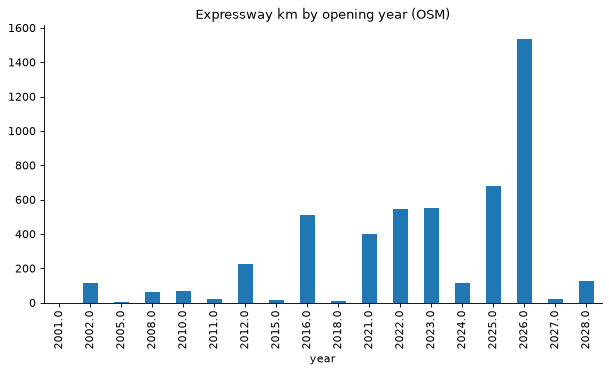

In [2]:
from fields.national_highways.normalize import parse_year

seg = nh.segments()
e = seg[seg.kind == "expressway_segment"].copy()
e["year"] = e.opening.map(parse_year)
print(f"{e.year.notna().mean():.0%} of expressway ways carry an opening/start date")
e.dropna(subset=["year"]).groupby("year").eff_km.sum().plot.bar(title="Expressway km by opening year (OSM)");

completion
FY - 23   1,269.00
FY - 24   2,657.00
FY - 25   4,269.00
FY - 26   3,197.00
Name: length_km, dtype: float64

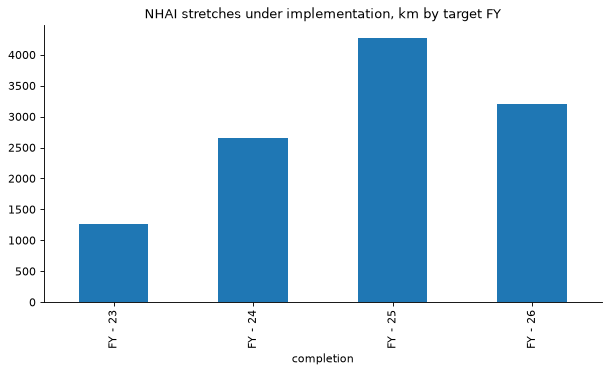

In [3]:
net = nh.nhai_network()
fy = net[net.status == "under_construction"].groupby("completion").length_km.sum().round(0)
fy.plot.bar(title="NHAI stretches under implementation, km by target FY"); fy

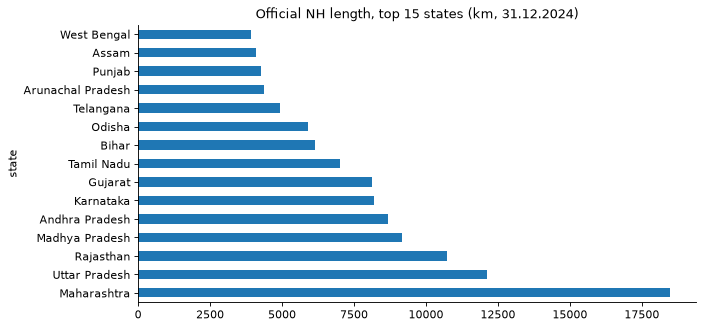

In [4]:
off = nh.official().sort_values("length_km", ascending=False)
off.head(15).plot.barh(x="state", y="length_km", legend=False, title="Official NH length, top 15 states (km, 31.12.2024)");